# Lab 0 Exercises
**Name:** Serge Ishimwe
**Student ID:** 58392028
**Course:** Introduction to AI - Semester 3, 2026

In [64]:
#Exercise 5

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

#Task 1: Data cleaning and exploration

print(df.info())
print("\nThe values that are missing: ")
print(df.isnull().sum)

#Filling missing exam_score with the mean score for the student's major

df['exam_score']=df.groupby('major')['exam_score'].transform(lambda x: x.fillna(x.mean()))

#Filling missing hours_studied with the median for the student's year

df['hours_studied']=df.groupby('year')['hours_studied'].transform(lambda x: x.fillna(x.median()))

print("\nValues that are missing after filling")
print(df.isnull().sum)

#Task2: Analysis

print("Task2: Analysis:")
avg_exam_score_by_major=df.groupby('major')['exam_score'].mean()
print("The Average exam score by major: ")
print(avg_exam_score_by_major.round(2))

best_major=avg_exam_score_by_major.idxmax()
print(f"\nMajor with highest average score: {best_major}")

correlation=df['hours_studied'].corr(df['exam_score'])
print(f"Correlation betweeen the hours studied and exam scores: {correlation:.4f}")

#The performance column
def categorize(score):
  if score >90:
    return 'Excellent'
  elif score >=80:
    return 'Average'
  else:
    return 'Needs Improvement'

df['performance']=df['exam_score'].apply(categorize)
print("\nPerformance distribution:")
print(df['performance'].value_counts())

#Task 3: Advanced Analysis

print("\n Task 3:Advanced Analysis: ")
group_stats=df.groupby(['major','year']).agg(
    students_num=('student_id', 'count'),
    avg_exam_score=('exam_score','mean'),
    avg_hours_studied=('hours_studied', 'mean')
).round(2)

print("Stats by major and year:")
print(group_stats)

top5Students=df.nlargest(5, 'exam_score')[['student_id','major','year','exam_score']]
print("\nThe top 5 students:")
print(top5Students)

pivot=df.pivot_table(values='exam_score', index='major', columns='year', aggfunc='mean').round(2)
print("Average Exam Score by major and year_Pivot Table")
print(pivot)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None

The values that are missing: 
<bound method DataFrame.sum of      student_id  major   year  exam_score  assignments_completed  \
0         False  False  False       False                  False   
1         False  False  False       False                  False   
2         False  False  False       False                  False   
3         False  False  False       False                  False   
4         F

/tmp/ipykernel_8782/3675203944.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='major', y='exam_score', order=major_order,


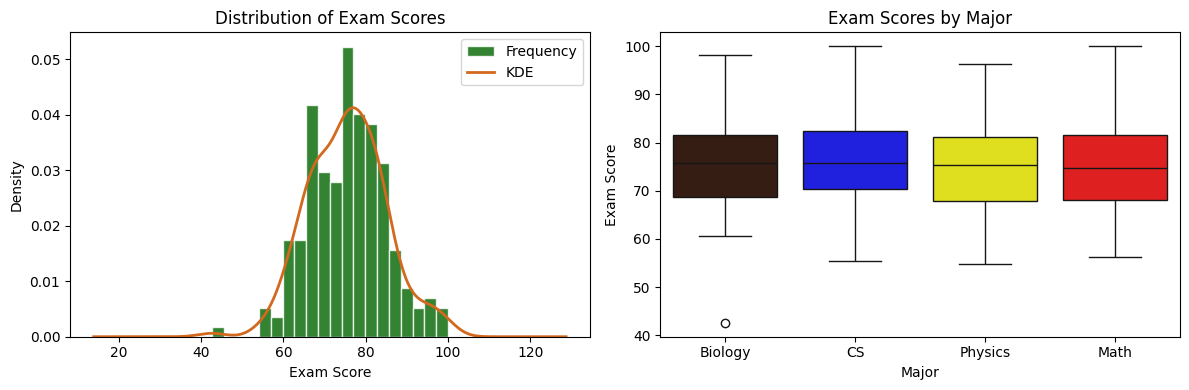

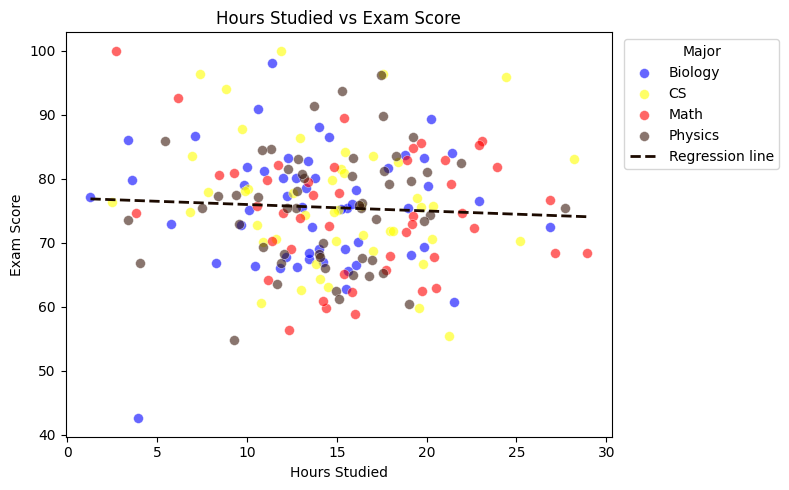

/tmp/ipykernel_8782/3675203944.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='performance', y='exam_score', order=perf_order,
/tmp/ipykernel_8782/3675203944.py:84: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(data=df, x='performance', y='exam_score', order=perf_order,


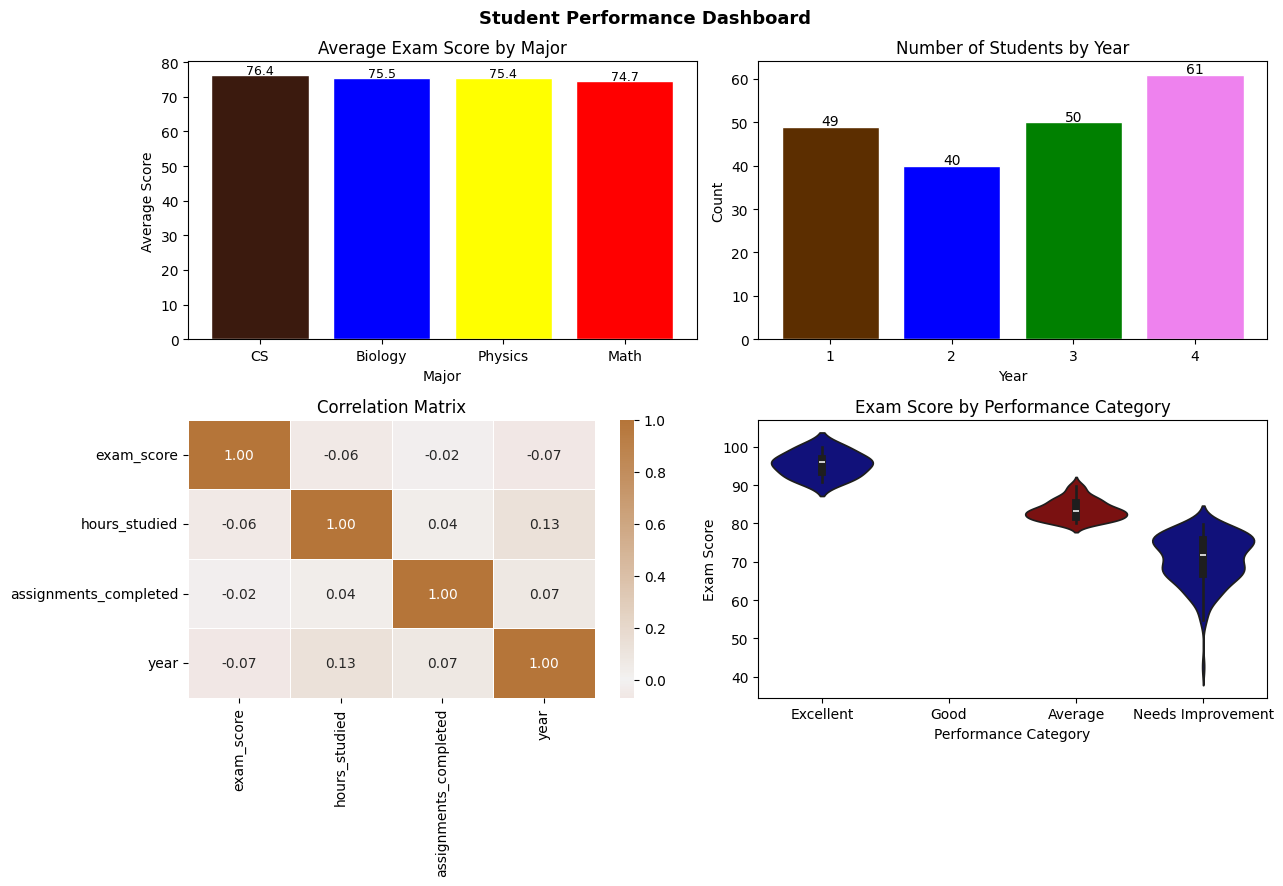

In [65]:
#Exercise 6

import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Distribution Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: Histogram with KDE overlay
ax1.hist(df['exam_score'], bins=20, density=True,
         color='darkgreen', edgecolor='white', alpha=0.8, label='Frequency')
df['exam_score'].plot.kde(ax=ax1, color='#D2691E', linewidth=2, label='KDE')
ax1.set_title('Distribution of Exam Scores')
ax1.set_xlabel('Exam Score')
ax1.set_ylabel('Density')
ax1.legend()

# Right: Box plot by major
major_order = df.groupby('major')['exam_score'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='major', y='exam_score', order=major_order,
            palette=['#3B1A0E', 'blue', 'yellow', 'red'], ax=ax2)
ax2.set_title('Exam Scores by Major')
ax2.set_xlabel('Major')
ax2.set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

# Task 2: Relationship Visualization
fig, ax = plt.subplots(figsize=(8, 5))

majors_list = df['major'].unique()
warm_palette = ['#3B1A0E', 'blue', 'yellow', 'red']
scatter_palette = dict(zip(majors_list, warm_palette))

for mjr, grp in df.groupby('major'):
    ax.scatter(grp['hours_studied'], grp['exam_score'], label=mjr, color=scatter_palette[mjr],
               alpha=0.6, s=50, edgecolors='white', linewidths=0.4)

reg_x = np.linspace(df['hours_studied'].min(), df['hours_studied'].max(), 200)
reg_coeffs = np.polyfit(df['hours_studied'].dropna(), df['exam_score'].dropna(), 1)
ax.plot(reg_x, np.polyval(reg_coeffs, reg_x),
        color='#1C0A00', linewidth=2, linestyle='--', label='Regression line')

ax.set_title('Hours Studied vs Exam Score')
ax.set_xlabel('Hours Studied')
ax.set_ylabel('Exam Score')
ax.legend(title='Major', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Task 3: Advanced Dashboard
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Student Performance Dashboard', fontsize=13, fontweight='bold')

# 1. Bar chart for the Average exam score by major
avg_by_major = df.groupby('major')['exam_score'].mean().sort_values(ascending=False)
axes[0, 0].bar(avg_by_major.index, avg_by_major.values, color=['#3B1A0E', 'blue', 'yellow', 'red'], edgecolor='white')
axes[0, 0].set_title('Average Exam Score by Major')
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Average Score')
for i, v in enumerate(avg_by_major.values):
  axes[0, 0].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=9)

# 2. Count plot for the Number of students by year
students_per_year = df['year'].value_counts().sort_index()
axes[0, 1].bar(students_per_year.index.astype(str), students_per_year.values,
               color=['#5C2E00', 'blue', 'green', 'violet'], edgecolor='white')
axes[0, 1].set_title('Number of Students by Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')
for i, v in enumerate(students_per_year.values):
    axes[0, 1].text(i, v + 0.3, str(v), ha='center', fontsize=10)

# 3. Heatmap for the Correlation matrix
numeric_cols = ['exam_score', 'hours_studied', 'assignments_completed', 'year']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap=sns.diverging_palette(20, 40, s=80, l=55, as_cmap=True),
            center=0, linewidths=0.5, ax=axes[1, 0])
axes[1, 0].set_title('Correlation Matrix')

# 4. Violin plot for the Exam score by performance category
perf_order = ['Excellent', 'Good', 'Average', 'Needs Improvement']
sns.violinplot(data=df, x='performance', y='exam_score', order=perf_order,
               palette=['darkblue', 'darkgreen', 'darkred'],
               inner='box', ax=axes[1, 1])
axes[1, 1].set_title('Exam Score by Performance Category')
axes[1, 1].set_xlabel('Performance Category')
axes[1, 1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

           num_customers  avg_income  avg_CLV  total_CLV
age_group                                               
18-25                 81    50634.02   718.37   58188.06
26-35                 73    48747.15   747.74   54584.92
36-50                160    48516.90   732.80  117247.46
51-70                186    50713.16   762.69  141860.99

Top 10% threshold: 1222.94
Count: 50


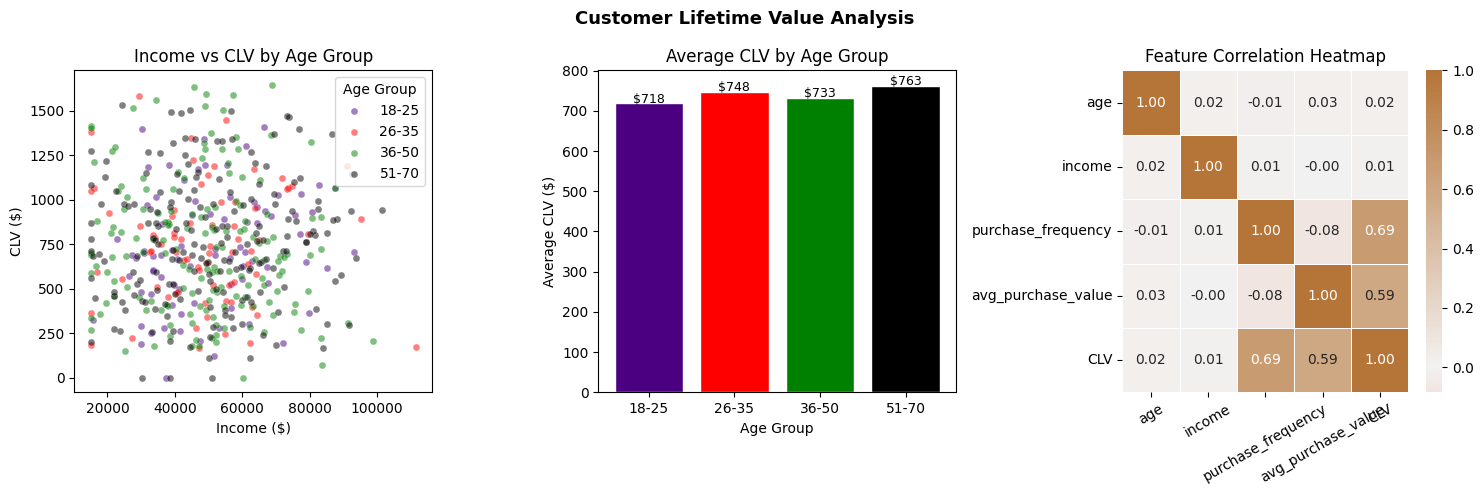

In [66]:
# Exercise 7

import pandas as pd
import numpy as np

np.random.seed(42)
n_customers = 500

ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# CLV calculation
max_frequency = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_frequency)
customers['CLV'] = (customers['purchase_frequency']
                    * customers['avg_purchase_value']
                    * (1 + customers['churn_risk']))

# Age groups
customers['age_group'] = pd.cut(customers['age'],
                                bins=[17, 25, 35, 50, 70],
                                labels=['18-25', '26-35', '36-50', '51-70'])

# Per-group summary
age_summary = customers.groupby('age_group', observed=True).agg(
    num_customers=('CLV', 'count'),
    avg_income=('income', 'mean'),
    avg_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
).round(2)

print(age_summary)

# Top 10% by CLV
top10_threshold = customers['CLV'].quantile(0.90)
top_customers = customers[customers['CLV'] >= top10_threshold]
print(f"\nTop 10% threshold: {top10_threshold:.2f}")
print(f"Count: {len(top_customers)}")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Customer Lifetime Value Analysis', fontsize=13, fontweight='bold')

group_colors = {'18-25': 'indigo', '26-35': 'red',
                '36-50': 'green', '51-70': 'black'}

# 1. Scatter for the income vs CLV by age group
for grp_label, grp_data in customers.groupby('age_group', observed=True):
    axes[0].scatter(grp_data['income'], grp_data['CLV'],
                    label=grp_label, color=group_colors[grp_label],
                    alpha=0.5, s=25, edgecolors='white', linewidths=0.3)
axes[0].set_title('Income vs CLV by Age Group')
axes[0].set_xlabel('Income ($)')
axes[0].set_ylabel('CLV ($)')
axes[0].legend(title='Age Group')

# 2. Bar chart for the average CLV by age group
bar_colors = [group_colors[g] for g in age_summary.index]
axes[1].bar(age_summary.index, age_summary['avg_CLV'],
            color=bar_colors, edgecolor='white')
axes[1].set_title('Average CLV by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average CLV ($)')
for i, v in enumerate(age_summary['avg_CLV']):
    axes[1].text(i, v + 1, f'${v:.0f}', ha='center', fontsize=9)

# 3. Correlation heatmap
corr_feats = ['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV']
sns.heatmap(customers[corr_feats].corr(), annot=True, fmt='.2f',
            cmap=sns.diverging_palette(20, 40, s=80, l=55, as_cmap=True),
            center=0, linewidths=0.5, ax=axes[2])
axes[2].set_title('Feature Correlation Heatmap')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Across all four age groups, the average CLV stays within a $45 range, which is surprising. The heatmap shows what is actually happening: income matters less, with a 0.01 correlation, but purchase frequency and average purchase value are the primary factors at 0.69 and 0.59, respectively. Because of that, a customer who earns $30,000 and shops frequently is worth more than a high earner who rarely shops. The top 10% starts at $1,222.94 and includes 50 customers. If we target that group, we should focus on buying behavior instead of income brackets.

In [67]:
#Exercise 4


import numpy as np;

# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0

border_matrix=np.ones((5,5))
border_matrix[1:-1, 1:-1]=0
print("The first task:")
print(border_matrix)

#Task 2: Normalize a random array

np.random.seed(42)
random_data=np.random.randn(100, 3)
normalized=(random_data-random_data.mean(axis=0))/random_data.std(axis=0)

print("\nTask2, Normalized data: ")
print(f"Mean: {normalized.mean(axis=0).round(4)}")
print(f"Std: {normalized.std(axis=0).round(4)}")

#Task 3: Linear regression using normal equation

X=np.random.randn(50, 3)
true_theta=np.array([2.5, -1.2, 3.7])
Y=X @ true_theta + np.random.randn(50) *0.1

#Normal equation: theta=(X^T X)^(-1) X^T Y

theta_hat=np.linalg.inv(X.T @ X) @ X.T @ Y

print("\n Task 3; Linear Regression Stuffs:")
print(f"True theta: {true_theta}")
print(f"Estimated theta: {theta_hat.round(4)}")



The first task:
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]

Task2, Normalized data: 
Mean: [-0.  0. -0.]
Std: [1. 1. 1.]

 Task 3; Linear Regression Stuffs:
True theta: [ 2.5 -1.2  3.7]
Estimated theta: [ 2.5172 -1.1978  3.724 ]
